In [1]:
import requests
import pandas as pd
from pytrends.request import TrendReq
from datetime import datetime
from dateutil.relativedelta import relativedelta
import time
import matplotlib.pyplot as plt



url = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/prc_hicp_manr"

params = {
    "geo": "DE",
    "coicop": "CP00",
    "unit": "RCH_A"
}

r = requests.get(url, params=params)
data = r.json()

time_index = data["dimension"]["time"]["category"]["index"]
values = data["value"]

rows = []

for date, idx in time_index.items():
    value = values.get(str(idx))
    rows.append({
        "month": date,
        "inflation_rate": value
    })

df_inflation = pd.DataFrame(rows)

df_inflation["month"] = pd.to_datetime(df_inflation["month"])

df_inflation = df_inflation.sort_values("month")



In [2]:
# nur 2024 bis 2025 behalten
df_2024_2025 = df_inflation[
    (df_inflation["month"] >= "2022-01-01") &
    (df_inflation["month"] <= "2024-12-31")
]

df_2024_2025



,month,inflation_rate
300,2022-01-01,5.1
301,2022-02-01,5.5
302,2022-03-01,7.6
303,2022-04-01,7.8
304,2022-05-01,8.7
305,2022-06-01,8.2
306,2022-07-01,8.5
307,2022-08-01,8.8
308,2022-09-01,10.9
309,2022-10-01,11.6


In [3]:
from pytrends.request import TrendReq
import pandas as pd

pytrends = TrendReq(hl="de-DE", tz=360)

keywords = ["Inflation", "Energiekosten", "Lebenshaltungskosten"]

dfs = []

for word in keywords:

    pytrends.build_payload([word], timeframe="2022-01-01 2024-12-31", geo="DE")

    df = pytrends.interest_over_time()

    df = df.drop(columns=["isPartial"])

    dfs.append(df)

# Daten zusammenführen
trends = pd.concat(dfs, axis=1)

trends.head()


,Inflation,Energiekosten,Lebenshaltungskosten
date,,,
2021-12-26,44,7,66
2022-01-02,67,11,89
2022-01-09,73,14,74
2022-01-16,55,14,78
2022-01-23,60,12,71


In [4]:
trends = trends.reset_index()
trends.columns
trends

,date,Inflation,Energiekosten,Lebenshaltungskosten
0,2021-12-26,44,7,66
1,2022-01-02,67,11,89
2,2022-01-09,73,14,74
3,2022-01-16,55,14,78
4,2022-01-23,60,12,71
...,...,...,...,...
153,2024-12-01,40,8,59
154,2024-12-08,38,8,63
155,2024-12-15,34,7,56
156,2024-12-22,25,6,69


In [5]:
trends["month"] = trends["date"].dt.to_period("M")
trends_monthly = trends.groupby("month").mean(numeric_only=True)
trends_monthly
trends_monthly = trends_monthly.reset_index()
trends_monthly

,month,Inflation,Energiekosten,Lebenshaltungskosten
0,2021-12,44.00,7.00,66.00
1,2022-01,64.20,13.60,77.40
2,2022-02,58.75,14.25,78.00
3,2022-03,76.25,47.25,84.00
4,2022-04,73.25,25.25,78.25
5,2022-05,75.60,20.80,71.40
6,2022-06,85.75,20.75,75.75
7,2022-07,76.00,28.80,79.20
8,2022-08,75.50,44.75,84.50
9,2022-09,91.75,59.00,76.75


In [6]:

# Min-Max Normalisierung (empfohlen für Visualisierung)

trends_scaled = trends.copy()

for col in ["Inflation", "Energiekosten", "Lebenshaltungskosten"]:
    trends_scaled[col] = (
        trends[col] - trends[col].min()
    ) / (trends[col].max() - trends[col].min())

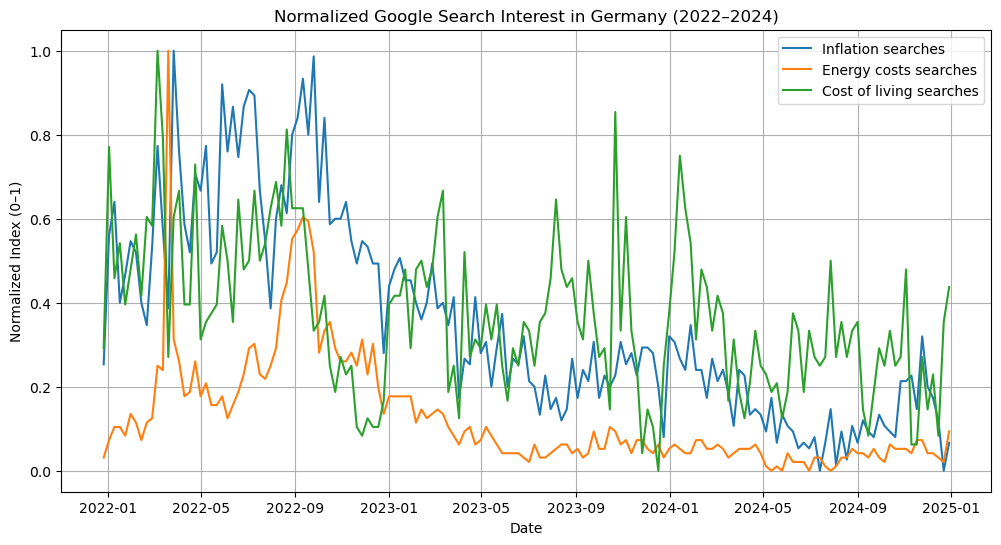

In [7]:

plt.figure(figsize=(12,6))

plt.plot(trends_scaled["date"], trends_scaled["Inflation"], label="Inflation searches")
plt.plot(trends_scaled["date"], trends_scaled["Energiekosten"], label="Energy costs searches")
plt.plot(trends_scaled["date"], trends_scaled["Lebenshaltungskosten"], label="Cost of living searches")

plt.legend()
plt.title("Normalized Google Search Interest in Germany (2022–2024)")
plt.xlabel("Date")
plt.ylabel("Normalized Index (0–1)")
plt.grid(True)

plt.show()

In [8]:
df_inflation["month"] = pd.to_datetime(df_inflation["month"])

trends_monthly["month"] = trends_monthly["month"].dt.to_timestamp()

rates_and_searches = pd.merge(
    df_2024_2025,
    trends_monthly,
    on="month",
    how="inner"
)

rates_and_searches

,month,inflation_rate,Inflation,Energiekosten,Lebenshaltungskosten
0,2022-01-01,5.1,64.20,13.60,77.40
1,2022-02-01,5.5,58.75,14.25,78.00
2,2022-03-01,7.6,76.25,47.25,84.00
3,2022-04-01,7.8,73.25,25.25,78.25
4,2022-05-01,8.7,75.60,20.80,71.40
5,2022-06-01,8.2,85.75,20.75,75.75
6,2022-07-01,8.5,76.00,28.80,79.20
7,2022-08-01,8.8,75.50,44.75,84.50
8,2022-09-01,10.9,91.75,59.00,76.75
9,2022-10-01,11.6,74.00,33.20,66.20


In [ ]:
from dotenv import load_dotenv
import os 

load_dotenv()

API_KEY = os.getenv("API_KEY") 

BASE_URL = "https://gnews.io/api/v4/search"

QUERY = "inflation OR Teuerung"
COUNTRY = "de"
LANG = "de"

start = datetime(2022, 1, 1)
end   = datetime(2025, 1, 1)  

rows = []
cur = start

while cur < end:
    nxt = cur + relativedelta(months=1)

    params = {
        "q": QUERY,
        "country": COUNTRY,
        "lang": LANG,
        # ISO 8601 mit Z (wichtig!)
        "from": cur.strftime("%Y-%m-%dT00:00:00Z"),
        "to":   (nxt - relativedelta(days=1)).strftime("%Y-%m-%dT23:59:59Z"),
        "max": 1,      # nur 1 Artikel; wir nutzen totalArticles als Count
        "page": 1,
        "apikey": API_KEY
    }

    r = requests.get(BASE_URL, params=params, timeout=30)

    if r.status_code == 429:
        print("429 -> warte 60s und versuche den Monat nochmal:", cur.strftime("%Y-%m"))
        time.sleep(60)
        continue

    r.raise_for_status()
    data = r.json()

    total = data.get("totalArticles")
    print("OK", cur.strftime("%Y-%m"), "from/to:", params["from"], params["to"], "news_count:", total)

    rows.append({"month": cur.strftime("%Y-%m-01"), "news_count": total})

    cur = nxt
    time.sleep(1.2)  # GNews: i.d.R. max ~1 request/sec im Free Plan

news_monthly = pd.DataFrame(rows)
news_monthly["month"] = pd.to_datetime(news_monthly["month"])
news_monthly.head()

OK 2022-01 from/to: 2022-01-01T00:00:00Z 2022-01-31T23:59:59Z news_count: 312
OK 2022-02 from/to: 2022-02-01T00:00:00Z 2022-02-28T23:59:59Z news_count: 267
OK 2022-03 from/to: 2022-03-01T00:00:00Z 2022-03-31T23:59:59Z news_count: 331
OK 2022-04 from/to: 2022-04-01T00:00:00Z 2022-04-30T23:59:59Z news_count: 372
OK 2022-05 from/to: 2022-05-01T00:00:00Z 2022-05-31T23:59:59Z news_count: 566
OK 2022-06 from/to: 2022-06-01T00:00:00Z 2022-06-30T23:59:59Z news_count: 729
OK 2022-07 from/to: 2022-07-01T00:00:00Z 2022-07-31T23:59:59Z news_count: 722
OK 2022-08 from/to: 2022-08-01T00:00:00Z 2022-08-31T23:59:59Z news_count: 649
OK 2022-09 from/to: 2022-09-01T00:00:00Z 2022-09-30T23:59:59Z news_count: 777
OK 2022-10 from/to: 2022-10-01T00:00:00Z 2022-10-31T23:59:59Z news_count: 682
OK 2022-11 from/to: 2022-11-01T00:00:00Z 2022-11-30T23:59:59Z news_count: 733
OK 2022-12 from/to: 2022-12-01T00:00:00Z 2022-12-31T23:59:59Z news_count: 524
OK 2023-01 from/to: 2023-01-01T00:00:00Z 2023-01-31T23:59:59Z ne

,month,news_count
0,2022-01-01,312
1,2022-02-01,267
2,2022-03-01,331
3,2022-04-01,372
4,2022-05-01,566


In [10]:
news_monthly.to_csv("../data/processed/news_monthly.csv", index=False)

In [11]:

rates_and_searches["month"] = pd.to_datetime(rates_and_searches["month"]).dt.to_period("M").dt.to_timestamp()
news_monthly["month"] = pd.to_datetime(news_monthly["month"]).dt.to_period("M").dt.to_timestamp()

In [12]:
final_data = rates_and_searches.merge(news_monthly, on="month", how="inner")
final_data

,month,inflation_rate,Inflation,Energiekosten,Lebenshaltungskosten,news_count
0,2022-01-01,5.1,64.20,13.60,77.40,312
1,2022-02-01,5.5,58.75,14.25,78.00,267
2,2022-03-01,7.6,76.25,47.25,84.00,331
3,2022-04-01,7.8,73.25,25.25,78.25,372
4,2022-05-01,8.7,75.60,20.80,71.40,566
5,2022-06-01,8.2,85.75,20.75,75.75,729
6,2022-07-01,8.5,76.00,28.80,79.20,722
7,2022-08-01,8.8,75.50,44.75,84.50,649
8,2022-09-01,10.9,91.75,59.00,76.75,777
9,2022-10-01,11.6,74.00,33.20,66.20,682


In [ ]:
import requests
import pandas as pd
from itertools import product


def fetch_eurostat_data(url, value_name):
    response = requests.get(url)
    response.raise_for_status()
    data = response.json()

    ids = data["id"]                      # Reihenfolge der Dimensionen
    sizes = data["size"]                  # Länge je Dimension
    values = data["value"]                # Beobachtungen
    dimensions = data["dimension"]

    # Labels je Dimension vorbereiten, sortiert nach ihrem Index
    dim_labels = {}
    for dim in ids:
        cat_index = dimensions[dim]["category"]["index"]
        sorted_labels = [label for label, _ in sorted(cat_index.items(), key=lambda x: x[1])]
        dim_labels[dim] = sorted_labels

    # Alle möglichen Kombinationen der Dimensionspositionen
    all_positions = list(product(*[range(s) for s in sizes]))

    rows = []
    for flat_idx_str, val in values.items():
        flat_idx = int(flat_idx_str)
        pos_tuple = all_positions[flat_idx]

        row = {}
        for dim_name, pos in zip(ids, pos_tuple):
            row[dim_name] = dim_labels[dim_name][pos]

        row[value_name] = val
        rows.append(row)

    df = pd.DataFrame(rows)

    # Zeitspalte umwandeln
    if "time" in df.columns:
        df["time"] = pd.PeriodIndex(df["time"], freq="M").to_timestamp()

    return df


energy_url = (
    "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/"
    "prc_hicp_midx?geo=DE&coicop=CP045&unit=I15&sinceTimePeriod=2022&untilTimePeriod=2024"
)

food_url = (
    "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/"
    "prc_hicp_midx?geo=DE&coicop=CP01&unit=I15&sinceTimePeriod=2022&untilTimePeriod=2024"
)

labour_url = (
    "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/"
    "une_rt_m?geo=DE&sinceTimePeriod=2022&untilTimePeriod=2024"
)

df_energy = fetch_eurostat_data(energy_url, "energy_price_index")
df_food = fetch_eurostat_data(food_url, "food_price_index")
df_labour = fetch_eurostat_data(labour_url, "unemployment_rate")

print("ENERGY")
print(df_energy.head(), "\n")

print("FOOD")
print(df_food.head(), "\n")

print("LABOUR")
print(df_labour.head(), "\n")

In [ ]:
df_labour.to_csv("data/raw/unemployment_rate_2022_2024.csv", index=False)

In [ ]:
df_energy.to_csv("data/raw/ernergy_cost.csv", index=False)


In [ ]:
df_food.to_csv("data/raw/fooprice_index.csv", index=False)


In [ ]:
df_labour_filtered = df_labour[
    (df_labour["s_adj"]=="SA")&
    (df_labour["unit"]=="PC_ACT")&
    (df_labour["age"]=="TOTAL")&
    (df_labour["sex"]=="T")
]
df_labour_filtered

In [ ]:
df_labour_filtered = df_labour_filtered.drop(["freq", "s_adj", "age", "unit", "sex", "geo"], axis=1)

In [ ]:
df_labour_filtered.columns

In [ ]:
df_food.columns
df_food = df_food.drop(["freq", "unit", "coicop", "geo"], axis=1)
df_energy

In [ ]:
df_energy.columns
df_energy = df_energy.drop(["freq", "unit", "coicop", "geo"], axis=1)
df_energy

In [ ]:
df_labour_filtered = df_labour_filtered.reset_index(drop=True)

In [ ]:
'''df_energy.to_csv('energy.csv')
df_food.to_csv('food.csv') 
df_labour_filtered.to_csv('labour.csv')
df_2024_2025.to_csv('inflation.csv') 
news_monthly.to_csv('news_monthly.csv')
trends_monthly.to_csv('trends_monthly.csv')'''


In [ ]:
df_2024_2025.reset_index(drop=True)

In [ ]:
'''trends_monthly.to_csv("../data/processed/trends_monthly.csv", index=False)'''